# 02 · Semiconductor Physics Validation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/02_physics_validation.ipynb)

Sanity-check the scaling and the PN-junction electrostatics the whole project rests on: built-in potential, and the depletion-region fields from the Scharfetter-Gummel solver.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.11.0+cu128


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)


## Built-in potential of a PN junction
For a step junction, $V_{bi}=V_T\ln(N_A N_D/n_i^2)$. We compare to the potential drop the SG solver produces at equilibrium.

In [3]:

NA = ND = 1e22
Vbi_analytic = VT*np.log(NA*ND/SILICON.n_i**2)
st = sg.solve(step(1e22), 0.0)
phi = st.phi
Vbi_sg = float(phi.max() - phi.min())
print(f"V_bi analytic = {Vbi_analytic:.4f} V")
print(f"V_bi from SG  = {Vbi_sg:.4f} V")
print(f"relative diff = {abs(Vbi_sg-Vbi_analytic)/Vbi_analytic:.2%}")


V_bi analytic = 0.7143 V
V_bi from SG  = 0.7143 V
relative diff = 0.00%


## Equilibrium band picture
Potential, field, and carrier densities across the junction.

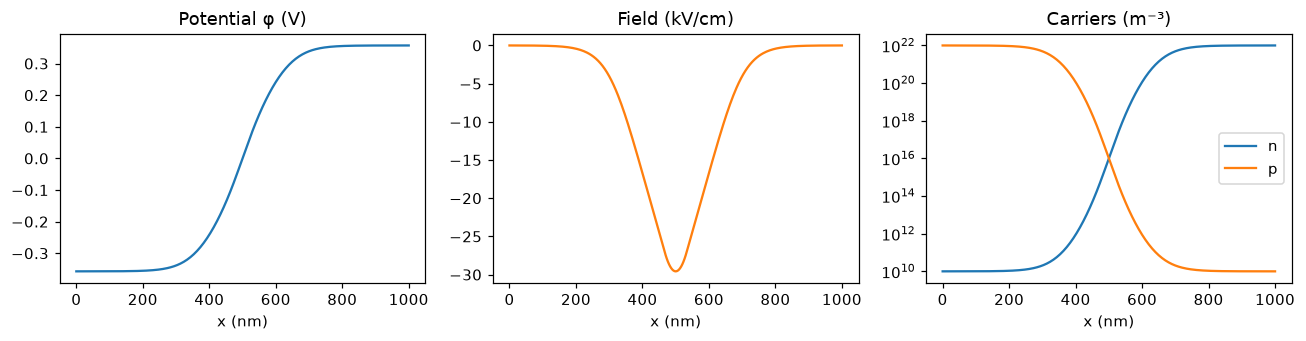

In [4]:

st = sg.solve(step(1e22), 0.0)
x_nm = np.linspace(0, 1000, len(st.phi))
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
ax[0].plot(x_nm, st.phi); ax[0].set_title("Potential φ (V)"); ax[0].set_xlabel("x (nm)")
E = -np.gradient(st.phi, x_nm*1e-9)
ax[1].plot(x_nm, E/1e5, color="C1"); ax[1].set_title("Field (kV/cm)"); ax[1].set_xlabel("x (nm)")
ax[2].semilogy(x_nm, np.abs(st.n)+1, label="n"); ax[2].semilogy(x_nm, np.abs(st.p)+1, label="p")
ax[2].set_title("Carriers (m⁻³)"); ax[2].set_xlabel("x (nm)"); ax[2].legend()
plt.tight_layout(); plt.show()
